# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 17     |  |
| :-------------|:-------------|
| Sam Lindner| 6391214 |
| Cedric Peignier| 6577458 |
| Eline Serpenti| 6506690 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Sam', 'Cedric']

## Opdracht 1: Planning.

| Planning Groep: 17     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren sensor | 12:00 |
| Ontwerpen algoritme | 14:00 |
| Itereren | 15:00 |
| groep aanwezig 1| 11:00-12:45 |
| groep aanwezig 2| 13:30-16:00 |
| Pauze 1| 12:45-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [17]
<img src="opstelling_kalibratie_echo_akoestisch_4_defd.jpeg" width="400">

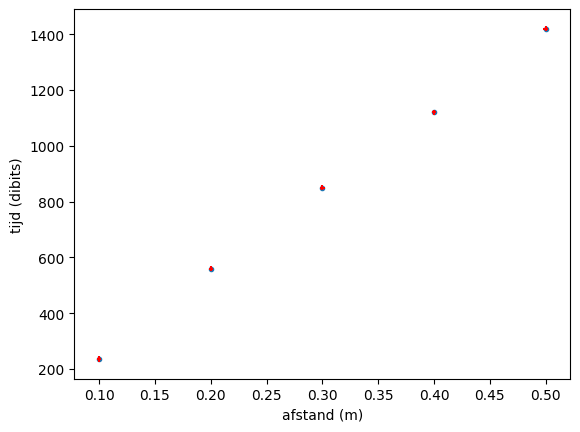

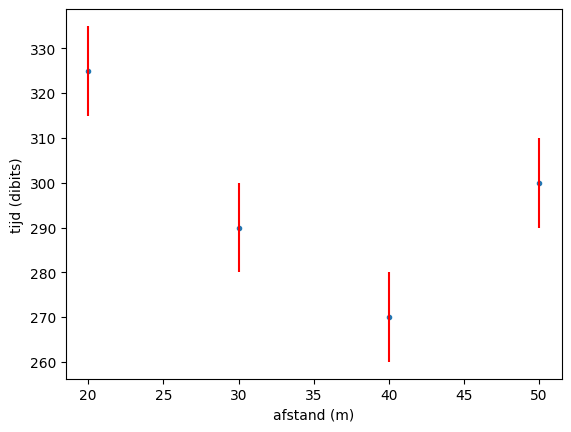

De gemiddelde tijd in dibbits voor een afstand van 10 cm na kalibratie is: 296.25 db
0.03375527426160337
10161.375
Het aantal s in 1 db is: 9.841187831371247e-05 s
a:0.035074764629868804 +/- 0.0004766451087028106
b:0.36366992800466236 +/- 0.49459243224213395


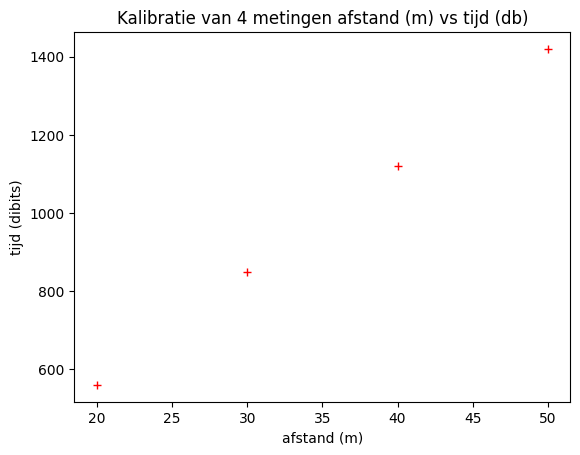

In [3]:
# verwerk hier jullie kalibratiemetingen
distance_between_src_rcvr = np.array([10,20,30, 40, 50]) / 100    # m
kalibratiemetingen = np.array([235, 560, 850, 1120, 1420 ])      # dibits

k_error = 10  # dibits
distance_error = 2/1000     # m

plt.figure()
plt.errorbar(distance_between_src_rcvr, kalibratiemetingen, 
             xerr=distance_error, yerr=k_error, fmt='.', ecolor='r', barsabove=True)
plt.ylabel('tijd (dibits)')
plt.xlabel('afstand (m)')
plt.show()
# verwijderen meting 1 want onnauwkeurig
meting10 = 235      #db
meting20= 560
meting30= 850
m40=1120
m50 = 1420
kmet2 = np.array([meting20-meting10, meting30- meting20, m40-meting30, m50-m40])        
distance_between_src_rcvr_2 = np.array([20,30,40,50])       # cm
plt.figure()
plt.errorbar(distance_between_src_rcvr_2, kmet2, 
             xerr=distance_error, yerr=k_error, fmt='.', ecolor='r', barsabove=True)
plt.ylabel('tijd (dibits)')
plt.xlabel('afstand (m)')
plt.show()
print ('De gemiddelde tijd in dibbits voor een afstand van 10 cm na kalibratie is:', np.mean(kmet2), 'db')
# berekening hoeveelheid tijd in 1 dibit
speed_sound = 343       # m/s # T=20 g
# dibits per tijd
dib_afstand = 1/ (np.mean(kmet2) /10)      # in 1 m
dib_tijd = speed_sound/dib_afstand
print(dib_afstand)     # aantal m in 1 dibit
print(dib_tijd) # aantal db in 1 s
print('Het aantal s in 1 db is:', 1/dib_tijd, 's')

# curve-fitting
from scipy.optimize import curve_fit

def function(x, a, b):
    return a*x+b

popt, pcov = curve_fit(function, kalibratiemetingen[1:], distance_between_src_rcvr_2)
a,b = popt
u_a = np.sqrt(pcov[0,0])
u_b = np.sqrt(pcov[1,1])
print(f'a:{a} +/- {u_a}')
print(f'b:{b} +/- {u_b}')
# kaLIBRATIE plot
plt.title('Kalibratie van 4 metingen afstand (m) vs tijd (db)')
plt.plot(distance_between_src_rcvr_2, kalibratiemetingen[1:], 'r+')
plt.ylabel('tijd (dibits)')
plt.xlabel('afstand (m)')
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  42.8
1   0  30   0  20  42.7
2  40   0  30   0  43.2
3  30   0  20   0  42.4


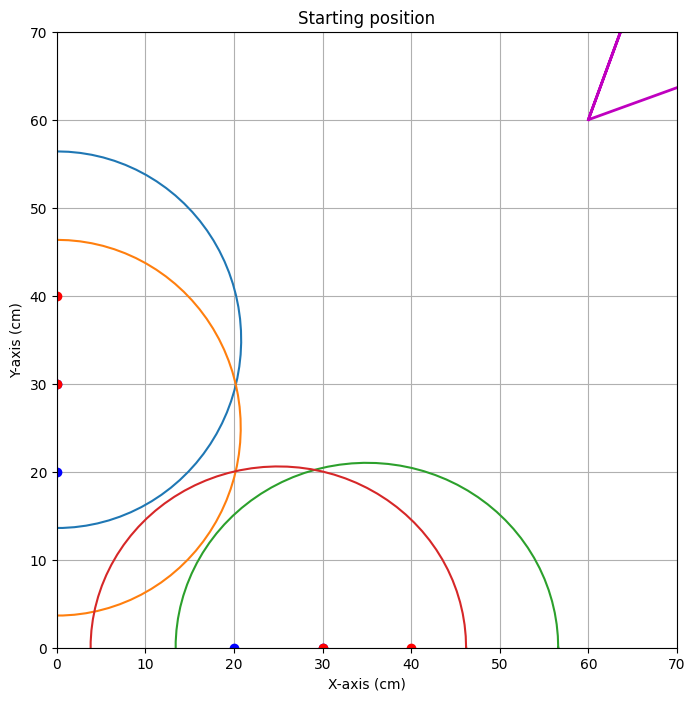


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.180


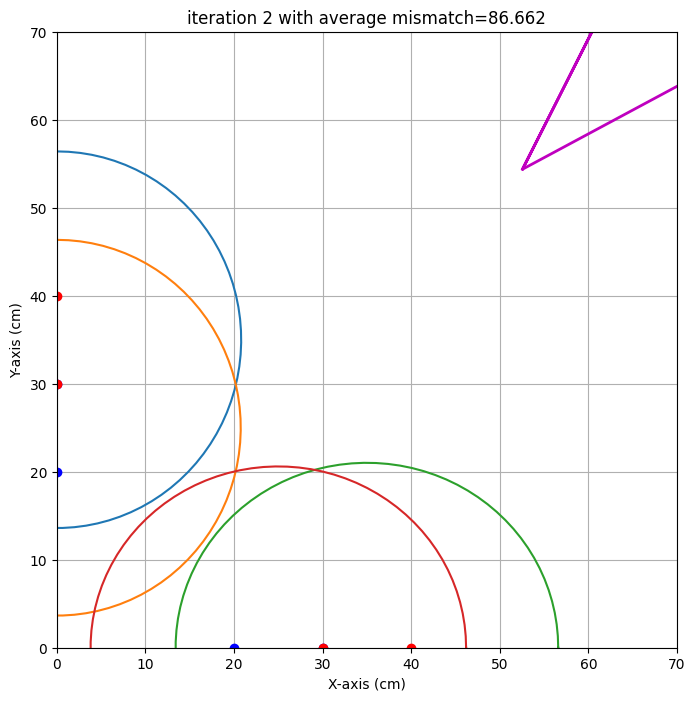

end iteration 2 with average mismatch=86.662


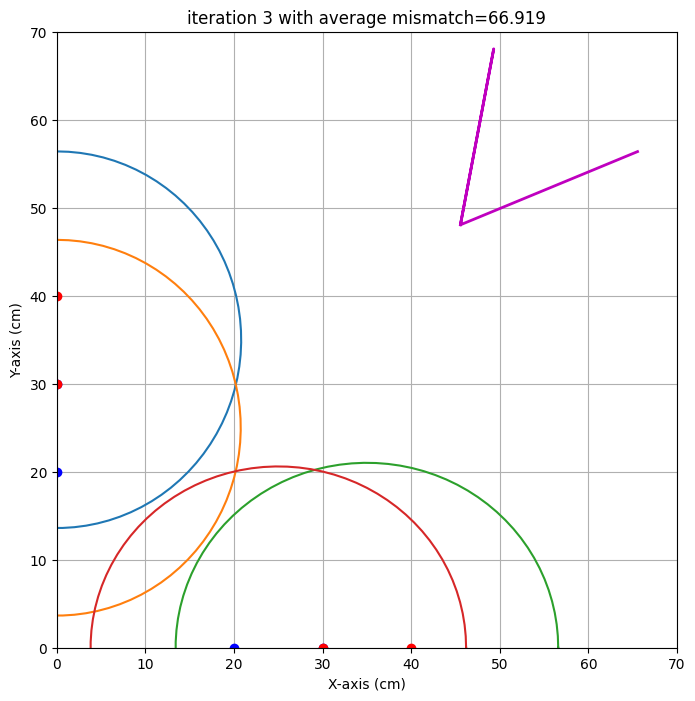

end iteration 3 with average mismatch=66.919


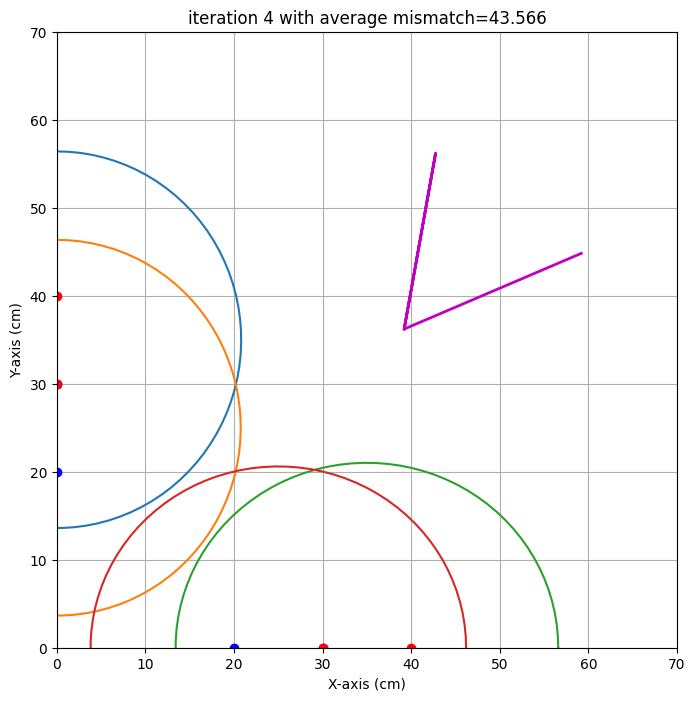

end iteration 4 with average mismatch=43.566


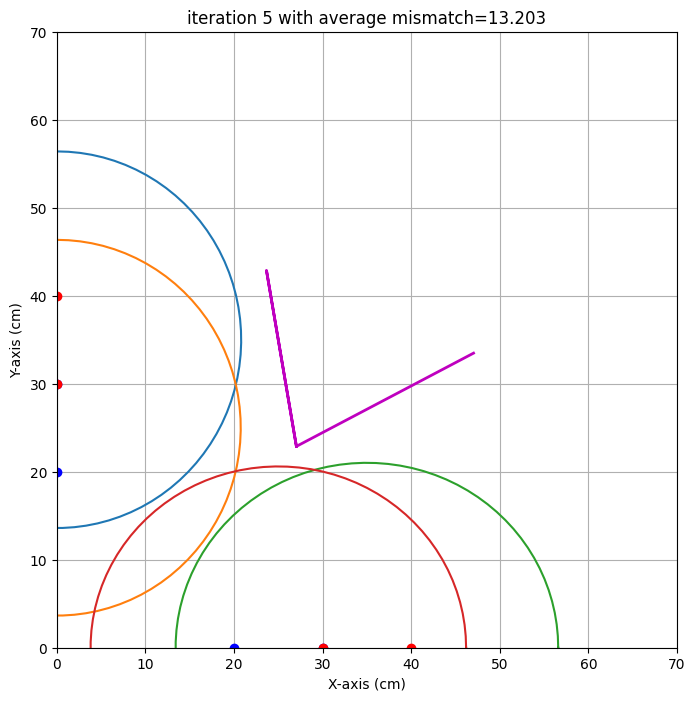

end iteration 5 with average mismatch=13.203


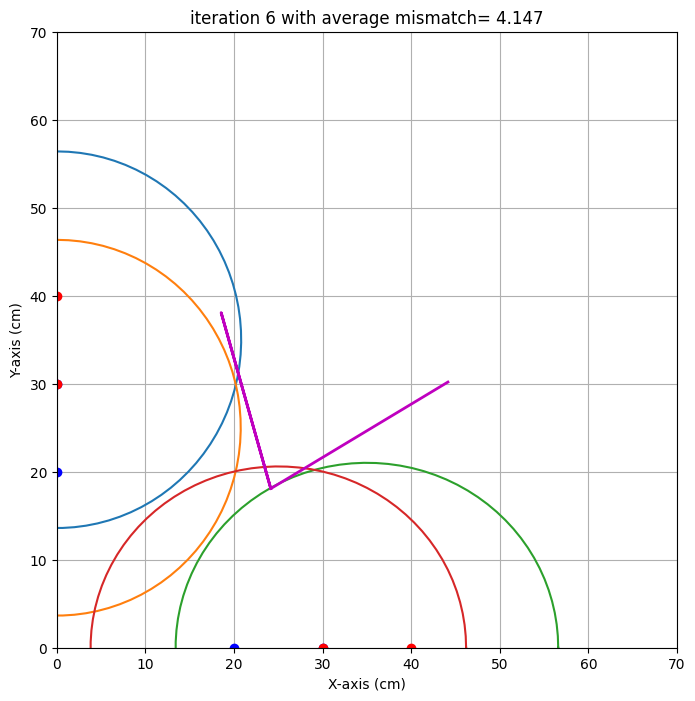

end iteration 6 with average mismatch= 4.147


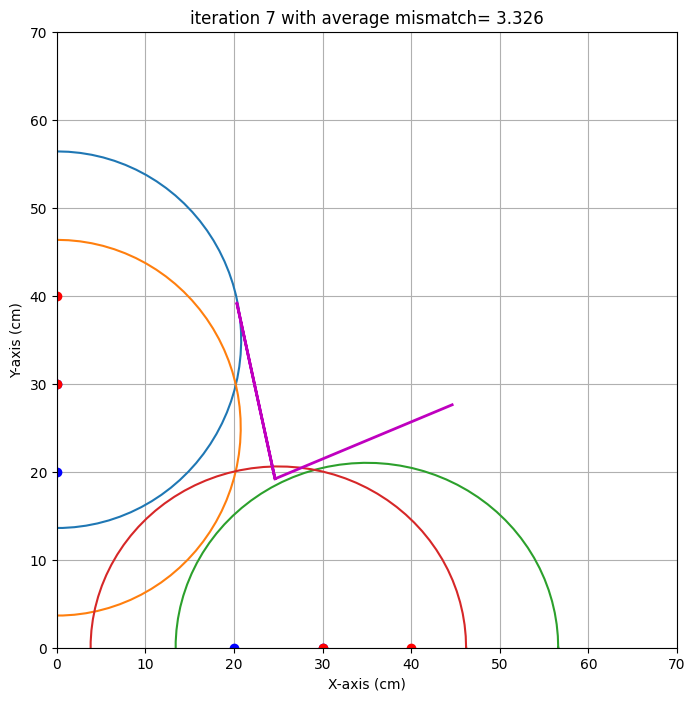

end iteration 7 with average mismatch= 3.326


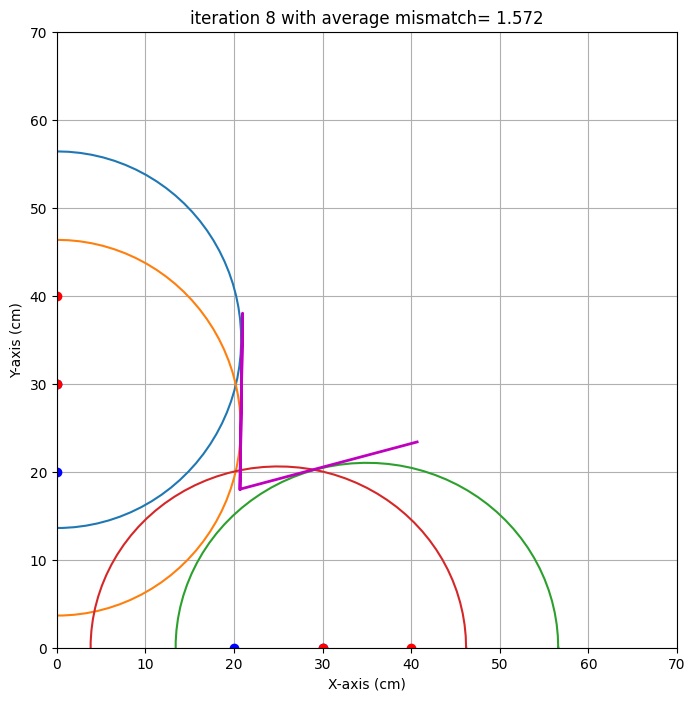

end iteration 8 with average mismatch= 1.572


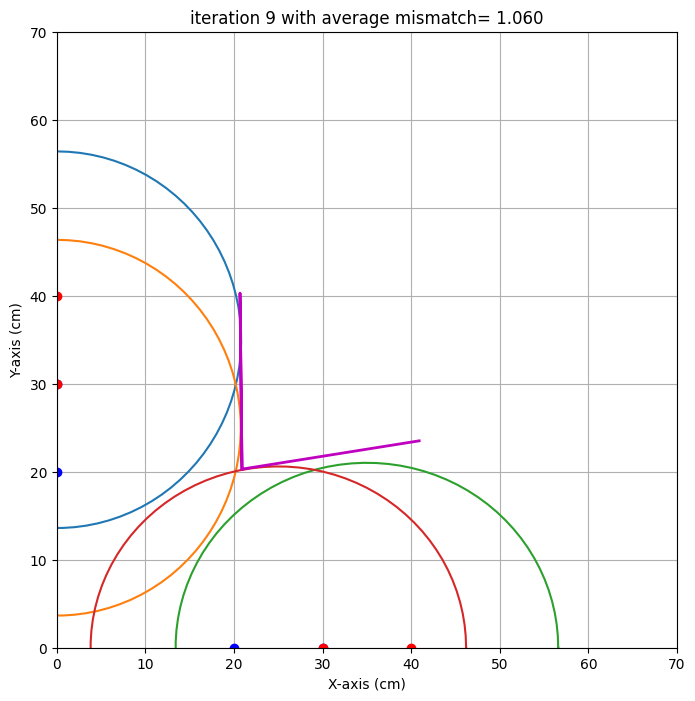

end iteration 9 with average mismatch= 1.060


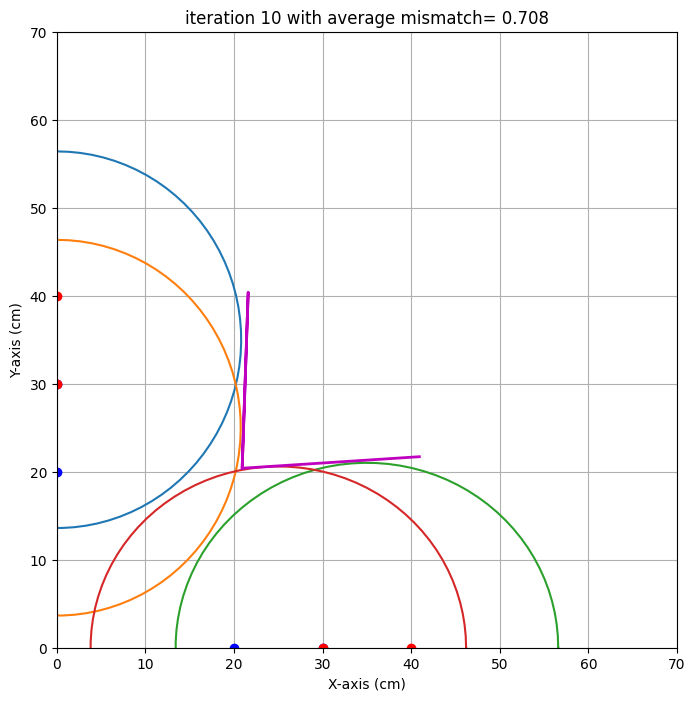

end iteration 10 with average mismatch= 0.708


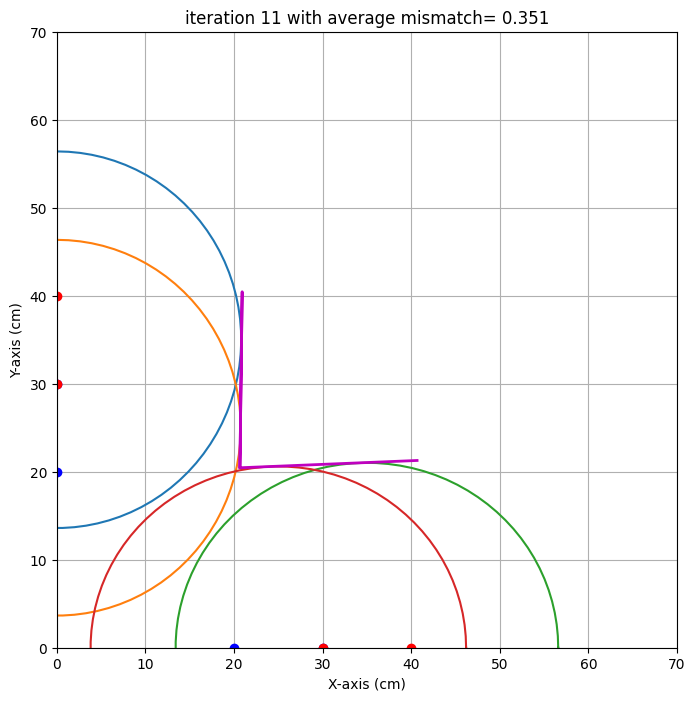

end iteration 11 with average mismatch= 0.351


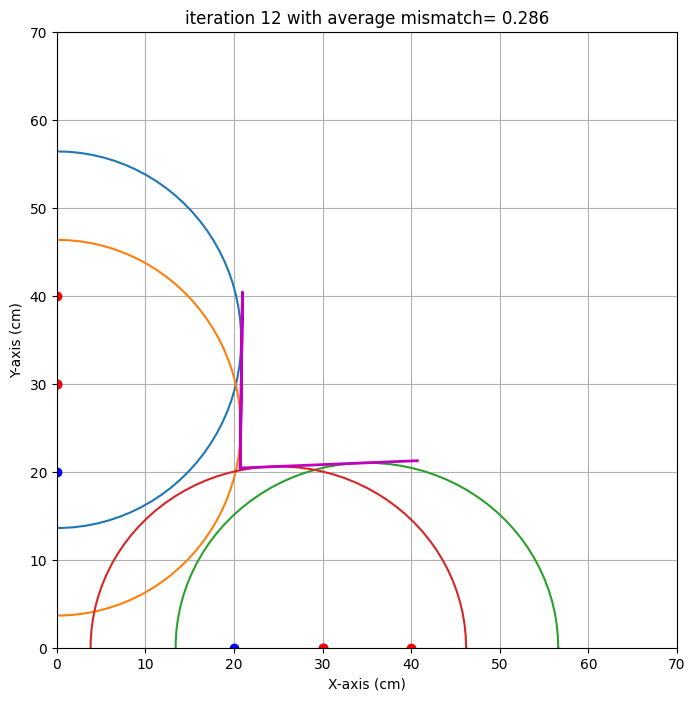

end iteration 12 with average mismatch= 0.286
end iteration 13 with average mismatch= 0.285
end iteration 14 with average mismatch= 0.285
end iteration 15 with average mismatch= 0.285
end iteration 16 with average mismatch= 0.285
end iteration 17 with average mismatch= 0.285
end iteration 18 with average mismatch= 0.285
end iteration 19 with average mismatch= 0.280
end iteration 20 with average mismatch= 0.266
end iteration 21 with average mismatch= 0.262
end iteration 22 with average mismatch= 0.262
end iteration 23 with average mismatch= 0.262
end iteration 24 with average mismatch= 0.262
end iteration 25 with average mismatch= 0.262
end iteration 26 with average mismatch= 0.262
end iteration 27 with average mismatch= 0.262
end iteration 28 with average mismatch= 0.262
end iteration 29 with average mismatch= 0.262
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.262
#################

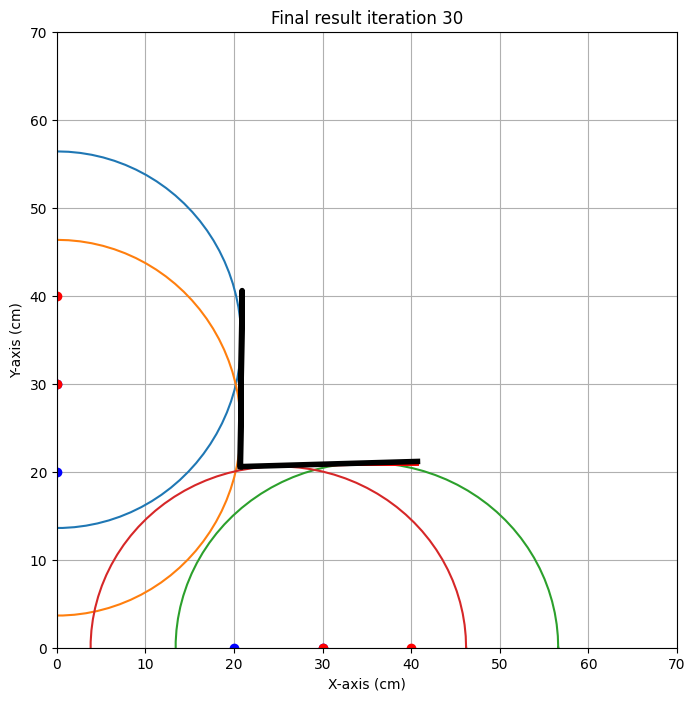

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,42.8],
    [0,30,0,20,42.7],
    #[0,10,0,20,0.36],
    [40,0,30,0,43.2],
    [30,0,20,0,42.4],
    #[10,0,20,0,0.36],
    #[10,0,0,10,0.36]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.7 cm met een standaardafwijking van 0.1 cm 
y0: 20.6 cm met een standaardafwijking van 0.1 cm 
alpha: 1.7 graden met een standaardafwijking van 1.3 graad 
beta: 0.6 graden met een standaardafwijking van 0.1 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Sam]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="Sam.jpeg" width="400">

## Uitleg Sam
The algorithim starts on the x-axis, the reciever is placed in the furthest point on that axis, the sensor at the origin placed at a 45 degree outward facing angle, measurements are taken every 10cm until the reciever is 10cm from the origin. the proceedure is repeated following the y-axis, until the reciever is again 10cm away from the origin along the y-axis.

#### algoritme [Cedric]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Cedric.jpeg" width="400">

## Uitleg Cedric
Door de source op de x-as te zetten en de reciever op de y-as, kan je ipv. de afstand die de geluidsgolven afleggen meten, bekijken of er tussen de source en reciever wel of niet een obstakel staat. Hierdoor kan je erg snel al de helft van het veld elimineren van gemeten worden, of heb je direct de positie van het papier, waardoor je erg gericht kan gaan meten.

#### algoritme [Eline]
Voeg een foto in van het algoritme van het derde groepslid
<img src="Eline.jpeg" width="400">

## Uitleg Eline
Je zet source en receiver op uiterste rand en het midden van de y-as en kijkt of er een redelijke meting uitkomt. Als dit zo is, zet je receiver op uiterste rand en 3/4 van de y-as. Dit itereer je zodat je steeds nauwkeuriger uitkomt op de plaats van het hoekpunt. Analoog benader je het op de x-as.

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 36.6, #zelf aanvullen,    # cm
           'y0': 41.9, #zelf aanvullen,    # cm
           'alpha' : -44, #zelf aanvullen,
           'beta' : -10, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Cedric' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0, 20, 20, 0, 27.8]
    #[0,40, 40, 0, 57.2]
    #[0, 60, 60, 0, 86.5]
    #[0,61, 0, 55, 0.36]
    #[0,41 ,0,35 ,0.36]
    # [0, 21, 0, 15, 162]
    ]),
       'Sam' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,0,0, 60, 95],
    [0,0,0,50, 100],
    #[0,0,0,40, 0.36]
    #[0,0,0,30,0.36 ]
    #[0,0,0,80, 0.36 ]
    #[0,0,0,70,0.36]
    [0,0,60,0, 95],
    [0,0,50,0,93],
    [0,0,40, 0, 92],
    [0,0,30,0, 93.5],
    [0,0,20,0,102],
    [0,0,10,0,0.36]
    ])
      }

## Opdracht 7: Evaluatie.

Sam
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0   0   0  60   95.00
1   0   0   0  50  100.00
2   0   0  60   0   95.00
3   0   0  50   0   93.00
4   0   0  40   0   92.00
5   0   0  30   0   93.50
6   0   0  20   0  102.00
7   0   0  10   0    0.36


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


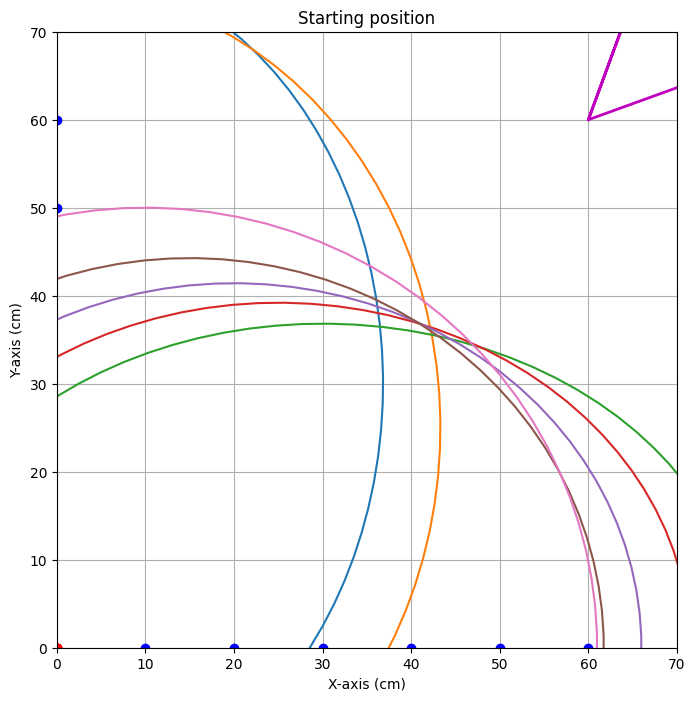


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=73.683


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


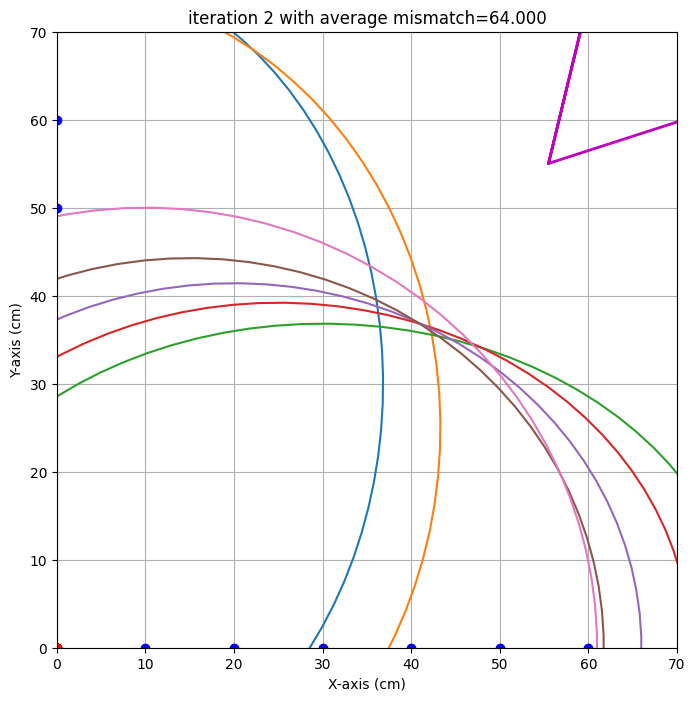

c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


end iteration 2 with average mismatch=64.000


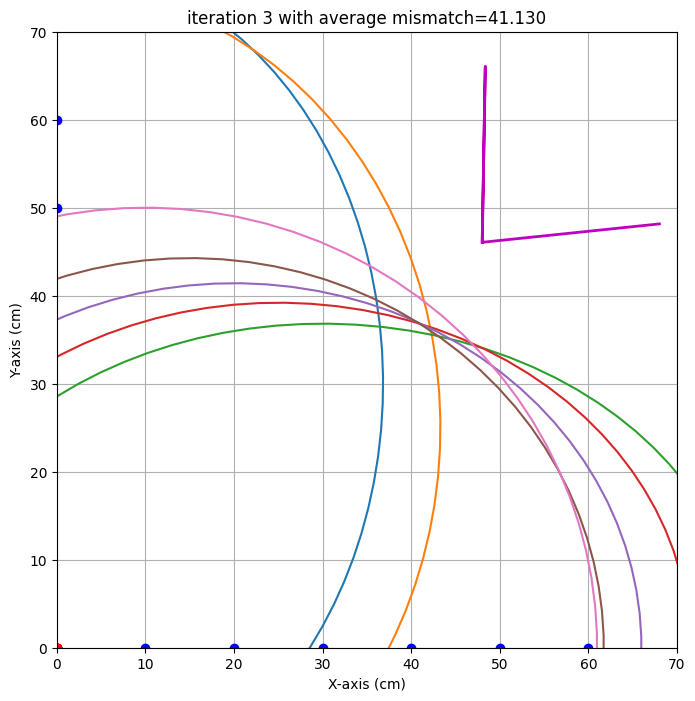

end iteration 3 with average mismatch=41.130


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


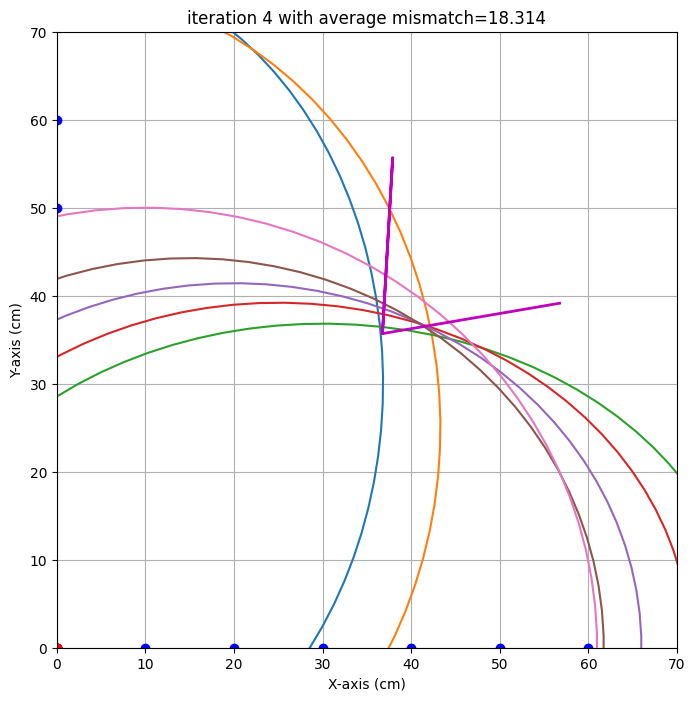

end iteration 4 with average mismatch=18.314
end iteration 5 with average mismatch=17.737
end iteration 6 with average mismatch=17.704
end iteration 7 with average mismatch=17.487
end iteration 8 with average mismatch=17.277
end iteration 9 with average mismatch=17.049
end iteration 10 with average mismatch=16.817
end iteration 11 with average mismatch=16.749
end iteration 12 with average mismatch=16.665
end iteration 13 with average mismatch=16.598
end iteration 14 with average mismatch=16.425
end iteration 15 with average mismatch=16.239
end iteration 16 with average mismatch=16.042
end iteration 17 with average mismatch=16.036
end iteration 18 with average mismatch=15.749
end iteration 19 with average mismatch=14.932
end iteration 20 with average mismatch=14.859
end iteration 21 with average mismatch=14.856
end iteration 22 with average mismatch=14.836
end iteration 23 with average mismatch=14.818
end iteration 24 with average mismatch=14.786
end iteration 25 with average mismatch=1

c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


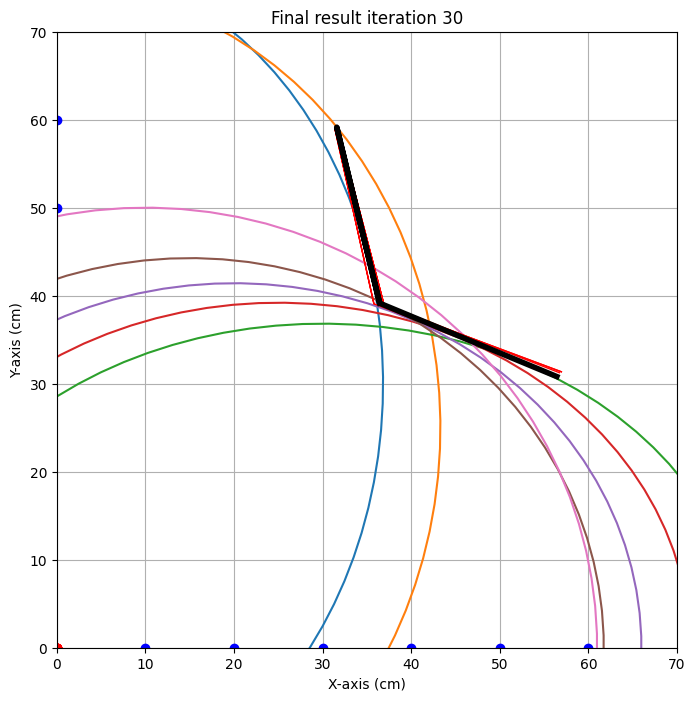

{'alpha': np.float64(-22.632151333668226), 'alpha_eps': np.float64(2.0289956697141953), 'beta': np.float64(-13.620966968823335), 'beta_eps': np.float64(1.3929777872410511), 'x0': np.float64(36.44210441837035), 'x0_eps': np.float64(0.6511488043039932), 'y0': np.float64(39.15217093992016), 'y0_eps': np.float64(0.2769765002683542)}
Cedric
Running the imaging algorithm with the following data:
Empty DataFrame
Columns: [xs, ys, xr, yr, R]
Index: []


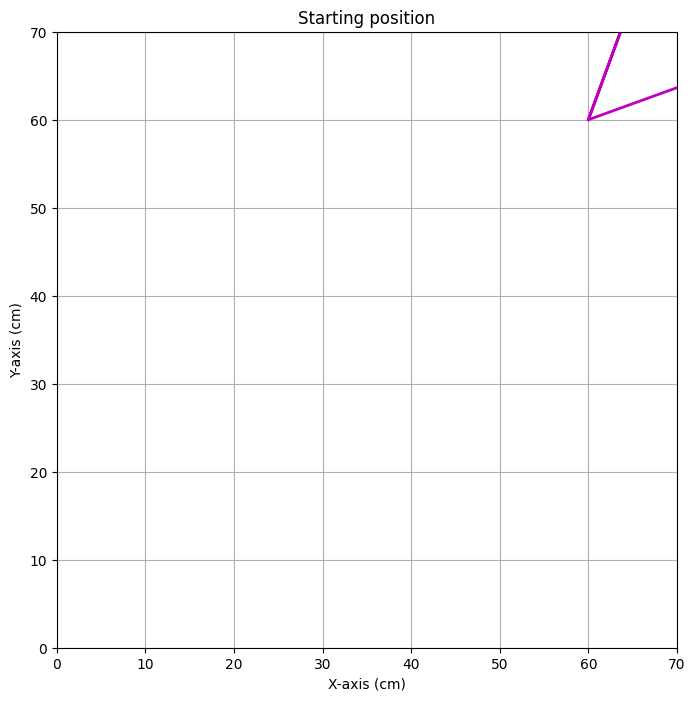


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with average mismatch=   nan
end iteration 22 with average mismatch=   nan
end iteration 23 with average mismatch=   nan
end iteration 24 with average mismatch=   nan
end iteration 25 with average mismatch=   nan
end iteration 26 with average mismatch=   nan
end iteration 27 with average mismatch=   nan
end iteration 28 with average mismatch=   nan
end iteration 29 with average mismat

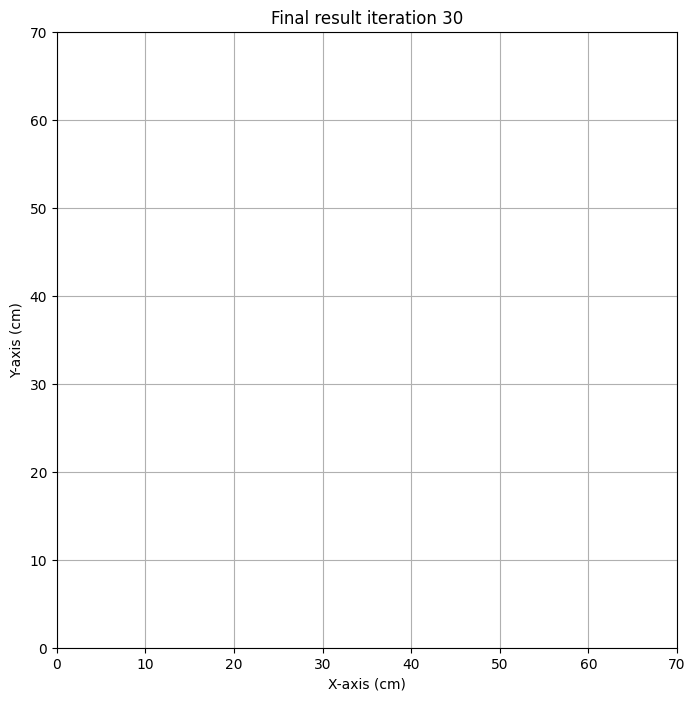

{'alpha': np.float64(nan), 'alpha_eps': 0.0, 'beta': np.float64(nan), 'beta_eps': 0.0, 'x0': np.float64(nan), 'x0_eps': 0.0, 'y0': np.float64(nan), 'y0_eps': 0.0}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Sam 
x0 target is : 36.6. Gevonden waarde: 36.4 cm met een standaardafwijking van 0.7 cm 
y0 target is : 41.9. Gevonden waarde: 39.2 cm met een standaardafwijking van 0.3 cm 
alpha target is : -44.0. Gevonden waarde: -22.6 graden met een standaardafwijking van 2.0 graad 
beta target is : -10.0. Gevonden waarde: -13.6 graden met een standaardafwijking van 1.4 graad 

Cedric 
x0 target is : 36.6. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 41.9. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : -44.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 
beta target is : -10.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 



## Opdracht 8: Iteratie1+. 15:28
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Final.algoritme.schets.combination.jpeg)
iteratie 3

In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0   0   0   0  60  116
1   0   0   0  50  119
2   0   0  70   0   99
3   0   0  75   0  101
4   0   0  65   0   98


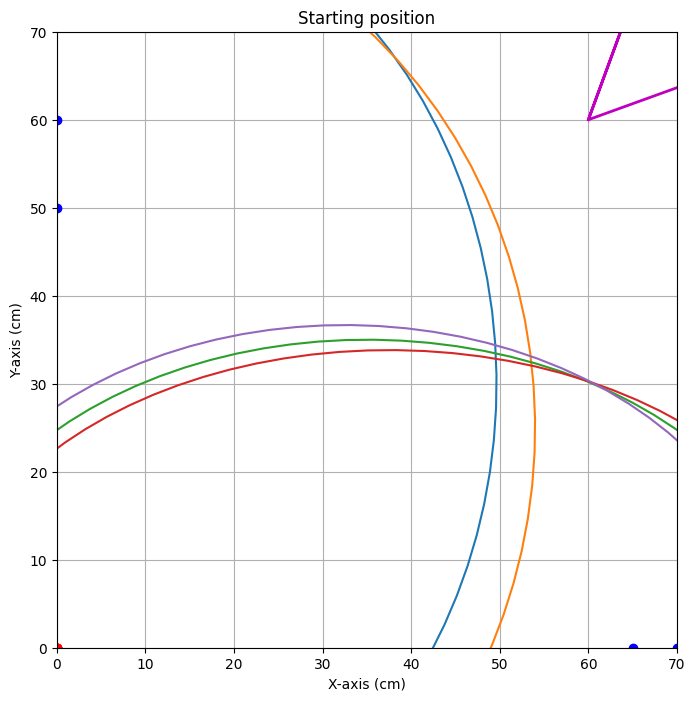


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.837


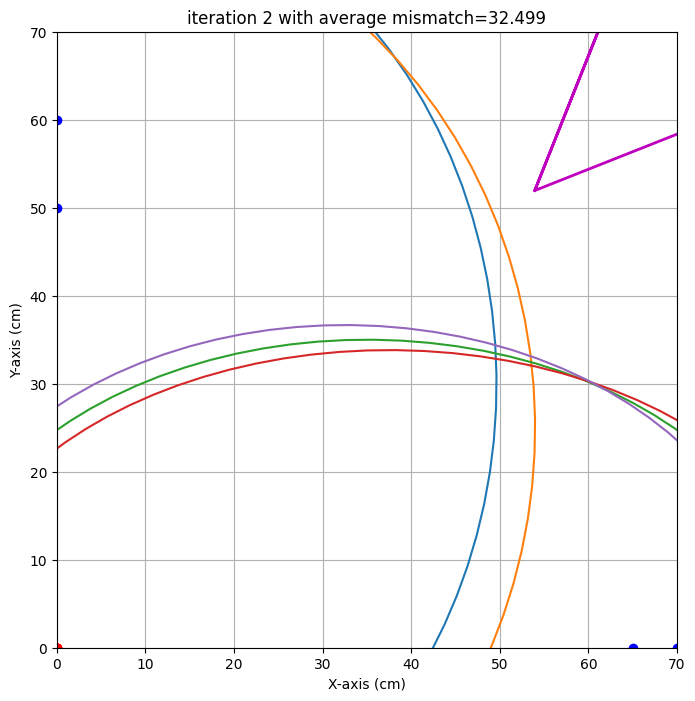

end iteration 2 with average mismatch=32.499


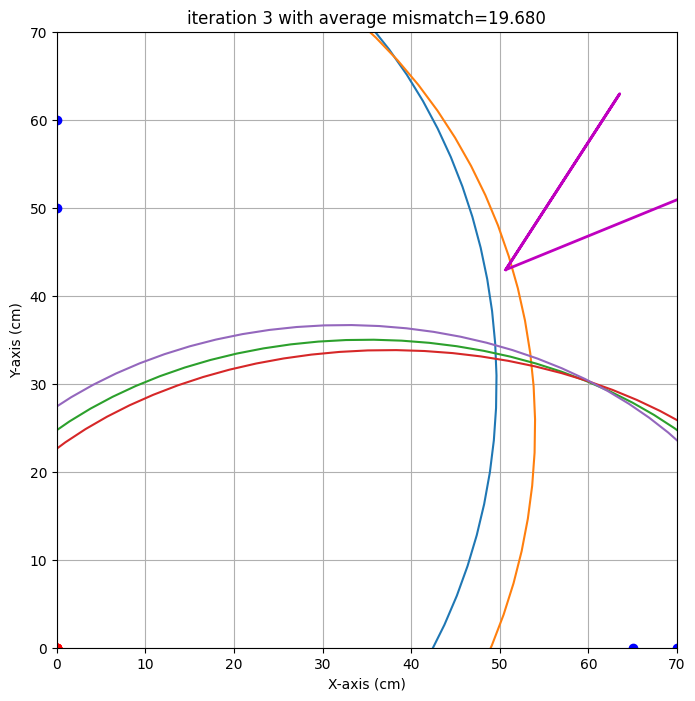

end iteration 3 with average mismatch=19.680


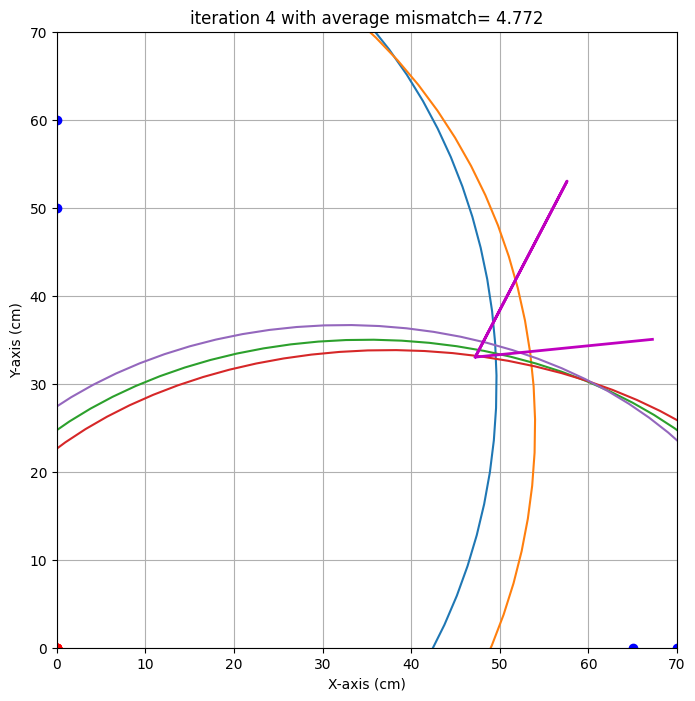

end iteration 4 with average mismatch= 4.772


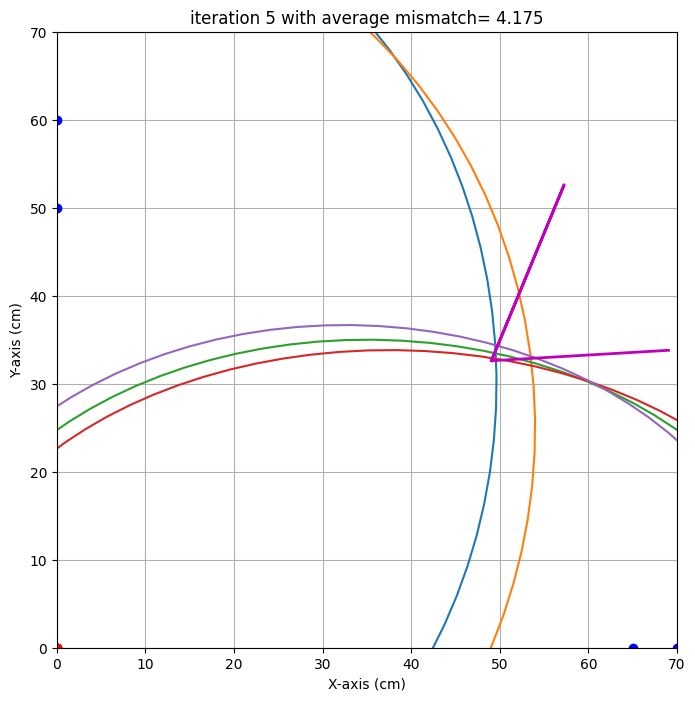

end iteration 5 with average mismatch= 4.175


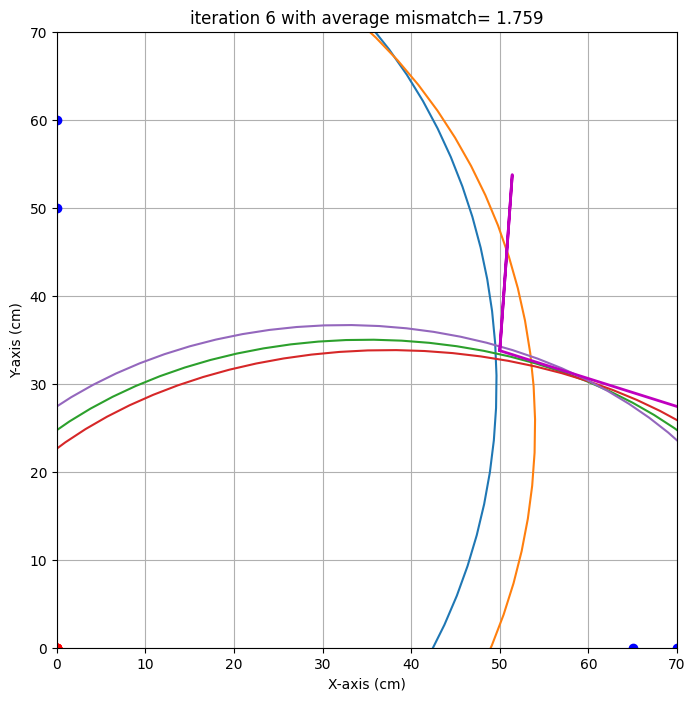

end iteration 6 with average mismatch= 1.759


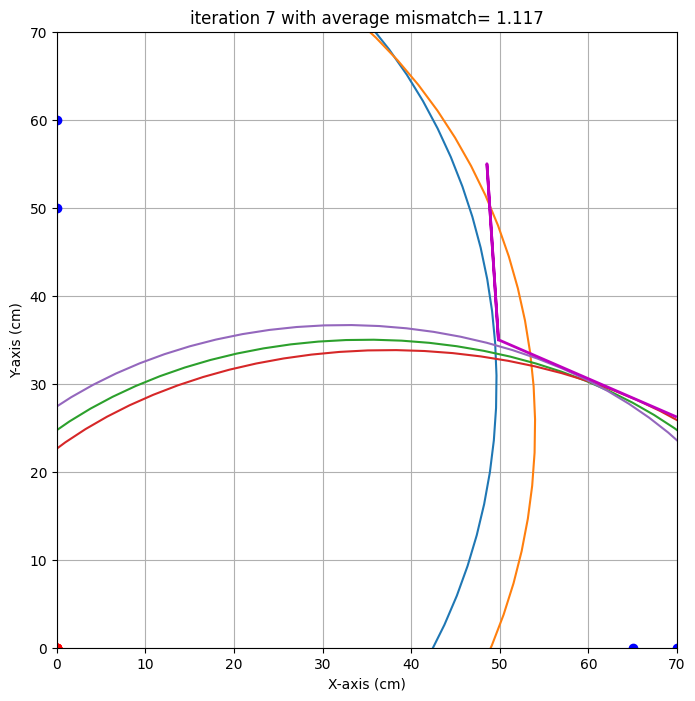

end iteration 7 with average mismatch= 1.117


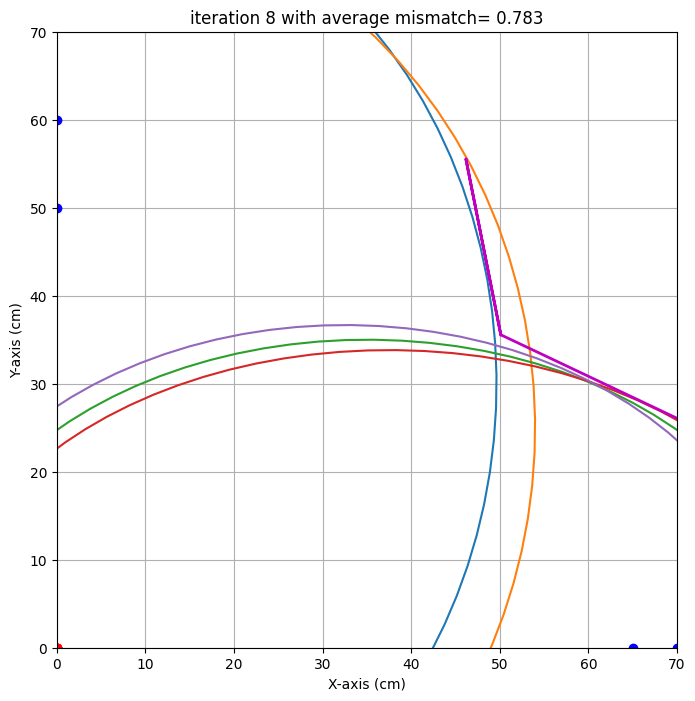

end iteration 8 with average mismatch= 0.783


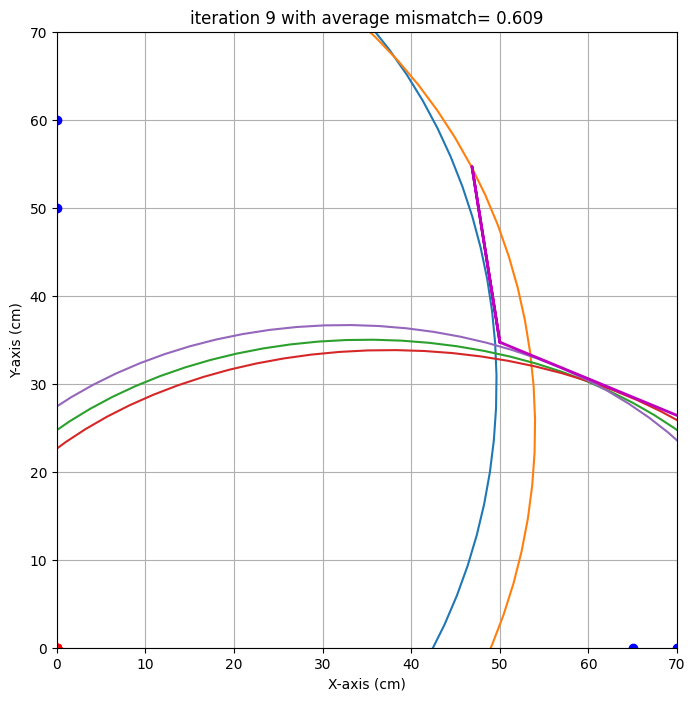

end iteration 9 with average mismatch= 0.609
end iteration 10 with average mismatch= 0.569
end iteration 11 with average mismatch= 0.567
end iteration 12 with average mismatch= 0.560
end iteration 13 with average mismatch= 0.559
end iteration 14 with average mismatch= 0.559
end iteration 15 with average mismatch= 0.559
end iteration 16 with average mismatch= 0.559
end iteration 17 with average mismatch= 0.559
end iteration 18 with average mismatch= 0.510
end iteration 19 with average mismatch= 0.504
end iteration 20 with average mismatch= 0.503
end iteration 21 with average mismatch= 0.503
end iteration 22 with average mismatch= 0.503
end iteration 23 with average mismatch= 0.503
end iteration 24 with average mismatch= 0.503
end iteration 25 with average mismatch= 0.503
end iteration 26 with average mismatch= 0.503
end iteration 27 with average mismatch= 0.503
end iteration 28 with average mismatch= 0.503
end iteration 29 with average mismatch= 0.503
Last iteration, also determine unce

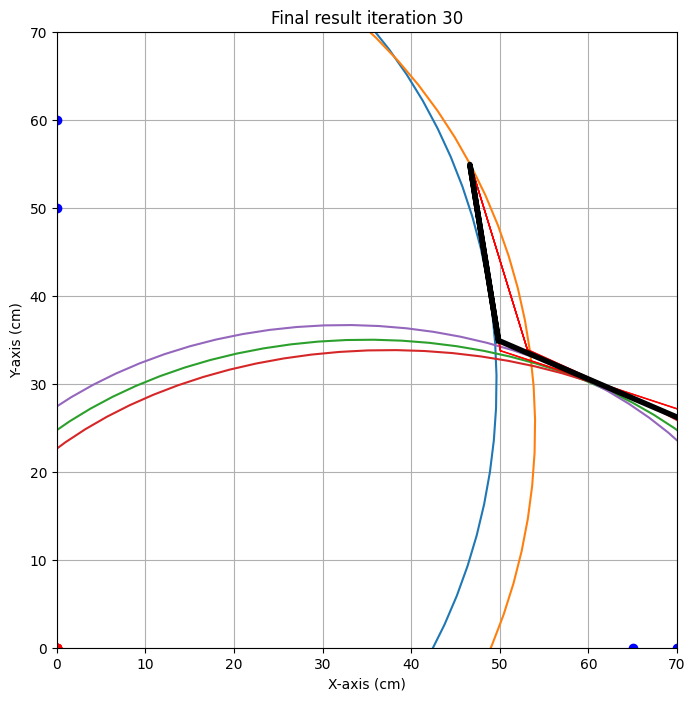

{'alpha': np.float64(-23.381276508462385), 'alpha_eps': np.float64(5.072173836574446), 'beta': np.float64(-9.18007205044763), 'beta_eps': np.float64(7.781417785000977), 'x0': np.float64(49.85746351314696), 'x0_eps': np.float64(3.256914629649849), 'y0': np.float64(34.90996370167154), 'y0_eps': np.float64(1.1641056979222313)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  50  53.10
1   0  30   0  40  50.60
2   0  20   0  30   0.36
3   0  35   0  45  50.00
4  40   0  50   0  54.20
5  30   0  40   0  53.30
6  20   0  30   0  53.20


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


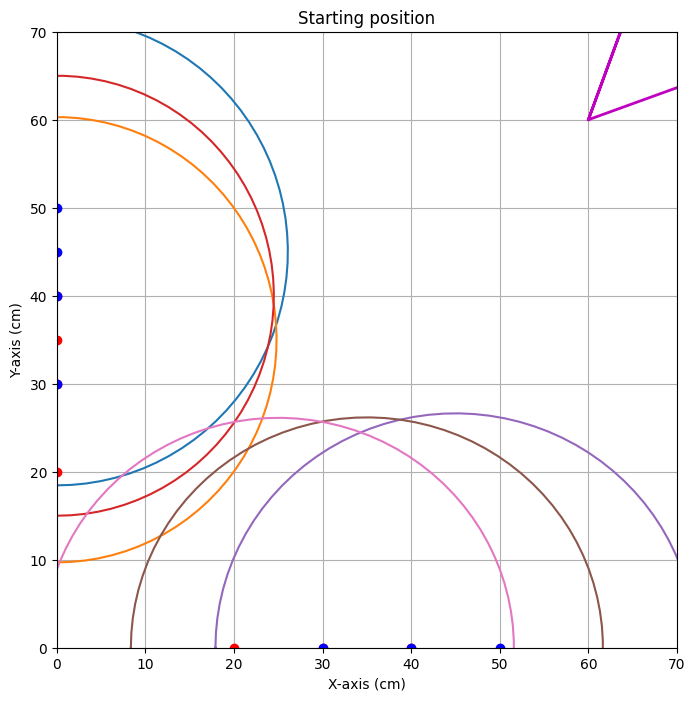


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=92.206


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


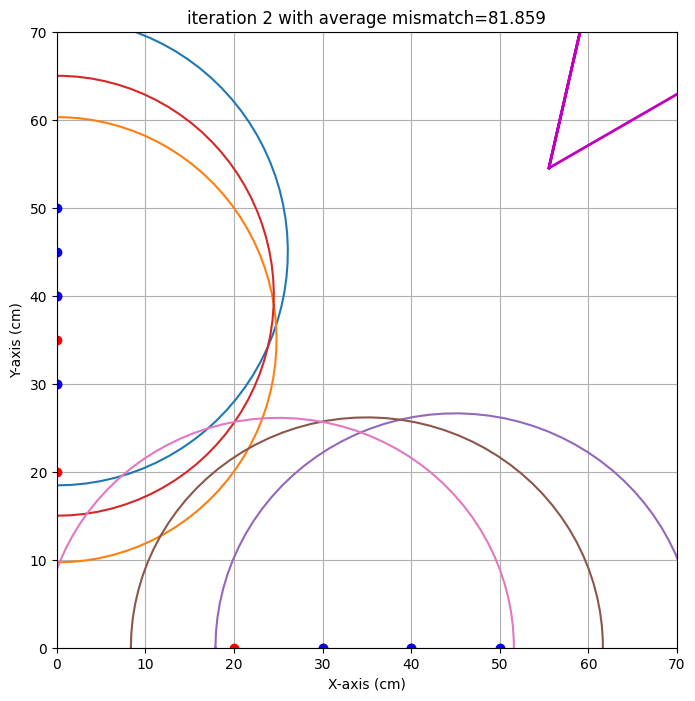

end iteration 2 with average mismatch=81.859


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


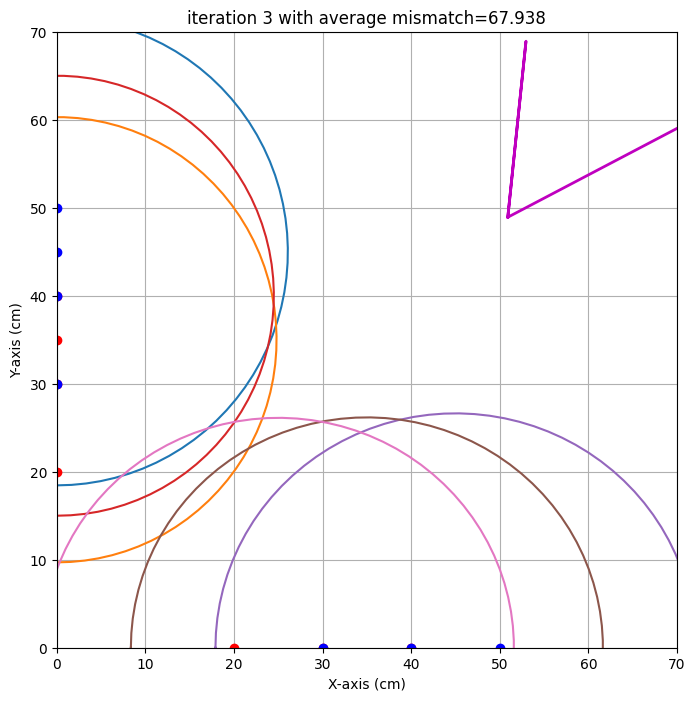

end iteration 3 with average mismatch=67.938


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


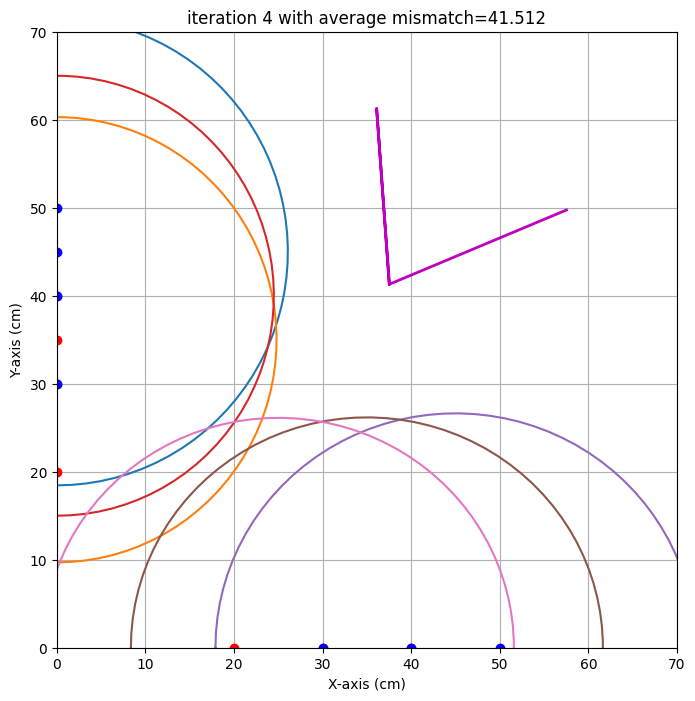

end iteration 4 with average mismatch=41.512


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


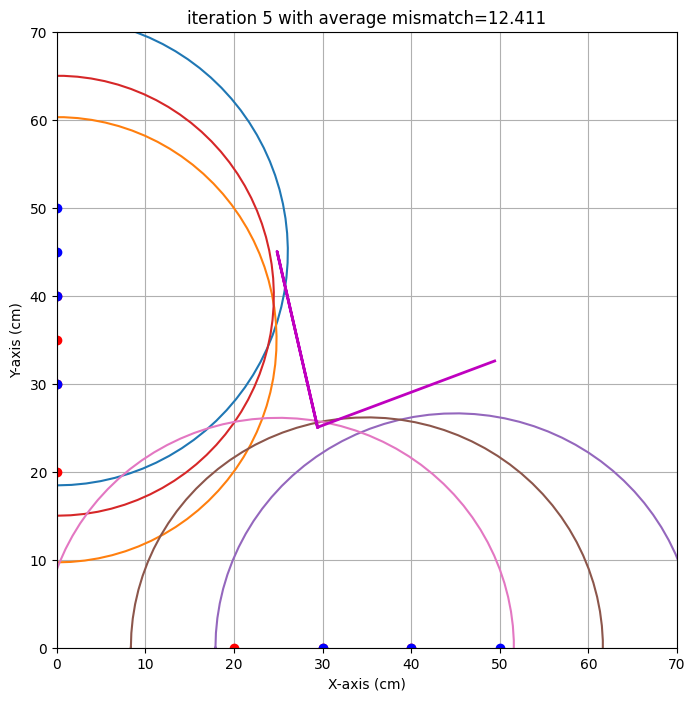

end iteration 5 with average mismatch=12.411


c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


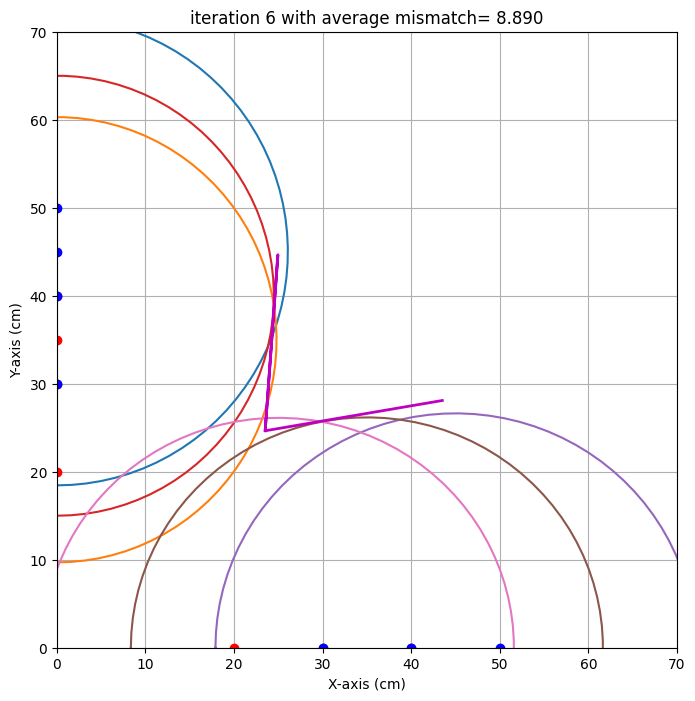

end iteration 6 with average mismatch= 8.890
end iteration 7 with average mismatch= 8.243
end iteration 8 with average mismatch= 7.886
end iteration 9 with average mismatch= 7.886
end iteration 10 with average mismatch= 7.886
end iteration 11 with average mismatch= 7.886
end iteration 12 with average mismatch= 7.886
end iteration 13 with average mismatch= 7.886
end iteration 14 with average mismatch= 7.886
end iteration 15 with average mismatch= 7.886
end iteration 16 with average mismatch= 7.886
end iteration 17 with average mismatch= 7.886
end iteration 18 with average mismatch= 7.886
end iteration 19 with average mismatch= 7.886
end iteration 20 with average mismatch= 7.886
end iteration 21 with average mismatch= 7.886
end iteration 22 with average mismatch= 7.886
end iteration 23 with average mismatch= 7.886
end iteration 24 with average mismatch= 7.886
end iteration 25 with average mismatch= 7.886
end iteration 26 with average mismatch= 7.886
end iteration 27 with average mismatch

c:\Users\Eline\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


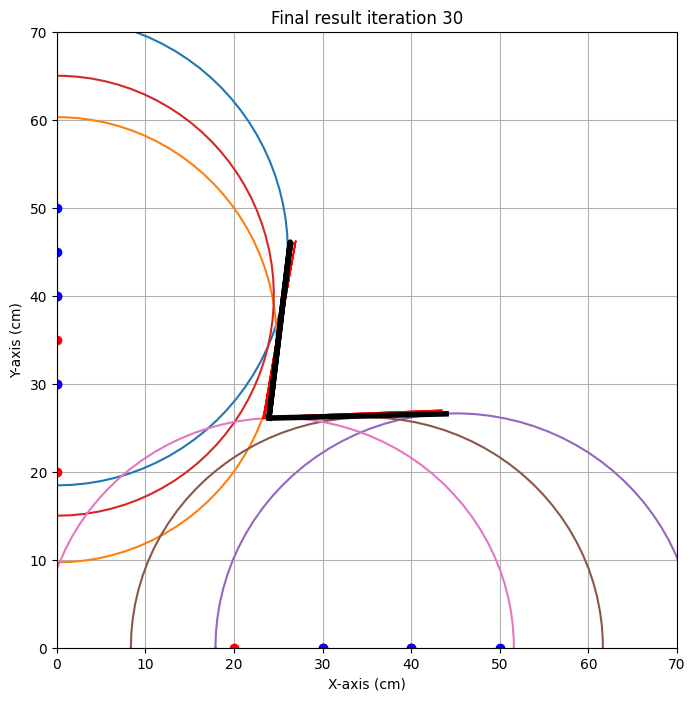

{'alpha': np.float64(1.3940648848642707), 'alpha_eps': np.float64(0.7942818132241023), 'beta': np.float64(6.868733678674971), 'beta_eps': np.float64(3.103967019521221), 'x0': np.float64(23.938969096576706), 'x0_eps': np.float64(0.6541160917135436), 'y0': np.float64(26.091940270336977), 'y0_eps': np.float64(0.12862381585999572)}
locatie 1 
x0 target is : 48.5. Gevonden waarde: 49.9 cm met een standaardafwijking van 3.3 cm 
y0 target is : 29.0. Gevonden waarde: 34.9 cm met een standaardafwijking van 1.2 cm 
alpha target is : 20.0. Gevonden waarde: -23.4 graden met een standaardafwijking van 5.1 graad 
beta target is : -1.0. Gevonden waarde: -9.2 graden met een standaardafwijking van 7.8 graad 

locatie 2 
x0 target is : 21.8. Gevonden waarde: 23.9 cm met een standaardafwijking van 0.7 cm 
y0 target is : 25.8. Gevonden waarde: 26.1 cm met een standaardafwijking van 0.1 cm 
alpha target is : -5.0. Gevonden waarde: 1.4 graden met een standaardafwijking van 0.8 graad 
beta target is : 5.0. G

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 48.5, #zelf aanvullen,
                    'y0': 29, #zelf aanvullen,
                    'alpha' : 20 ,#zelf aanvullen,
                    'beta' : -1 }, #zelf aanvullen,
           'locatie 2':{'x0': 21.8, #zelf aanvullen,
                    'y0': 25.8, #zelf aanvullen,
                    'alpha' : -5, #zelf aanvullen,
                    'beta' : 5} #zelf aanvullen
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,50,50,0,57.5] ongeldig
    #[0,60,60,0,85.5] ongeldig
    #-> niet in driehoek
    [0,0,0,60,116],
    [0,0,0,50,119],
    #[0,0,0,40,190] ongeldig
    #[0,0,0,45,186] ongeldig
    #[0,0,0,10,0.36] ongeldig
    #[0,0,80,0,0.36] ongeldig
    [0,0,70,0,99],
    #[0,0,60,0,0.36] ongeldig
    [0,0,75,0,101],
    [0,0,65,0,98]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [60,0, 0,60, 0.36] ongeldig
    # [55,0, 0, 55, 0.36 ] ongeldig
    # [50,0, 0, 50, 76.2] ongeldig
    #-> in driehoek
    [0,40, 0, 50, 53.1],
    [0,30, 0, 40, 50.6 ],
    [0, 20, 0, 30, 0.36],
    [0, 35, 0, 45, 50.0],
    [40,0,50 , 0, 54.2],
    [ 30,0, 40, 0, 53.3],
    [20, 0 , 30,0, 53.2]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  40  52.2
1  40   0  50   0  55.5
2   0  38   0  48  55.5
3  35   0  45   0  52.0


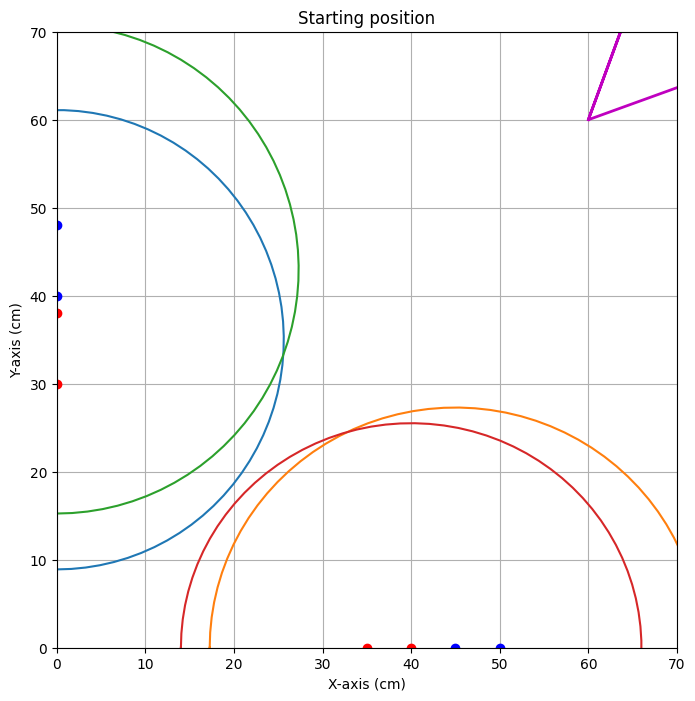


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.633


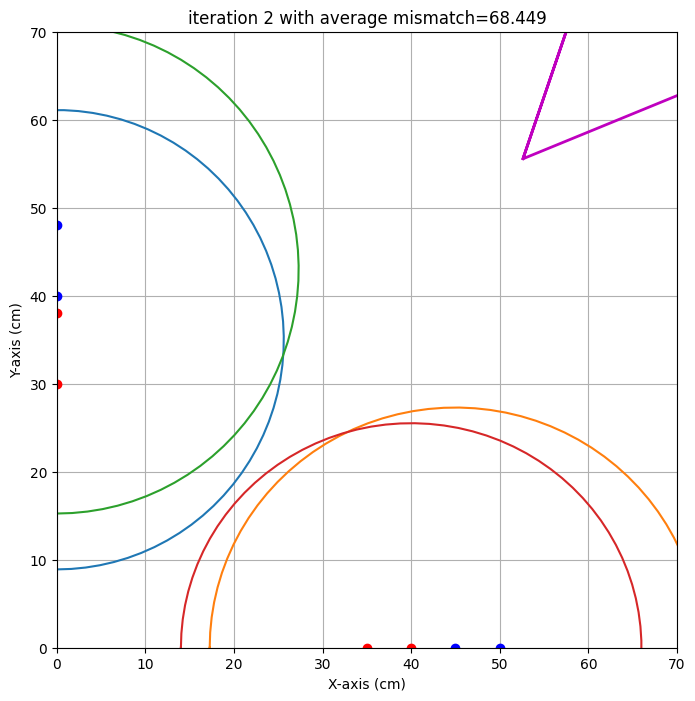

end iteration 2 with average mismatch=68.449


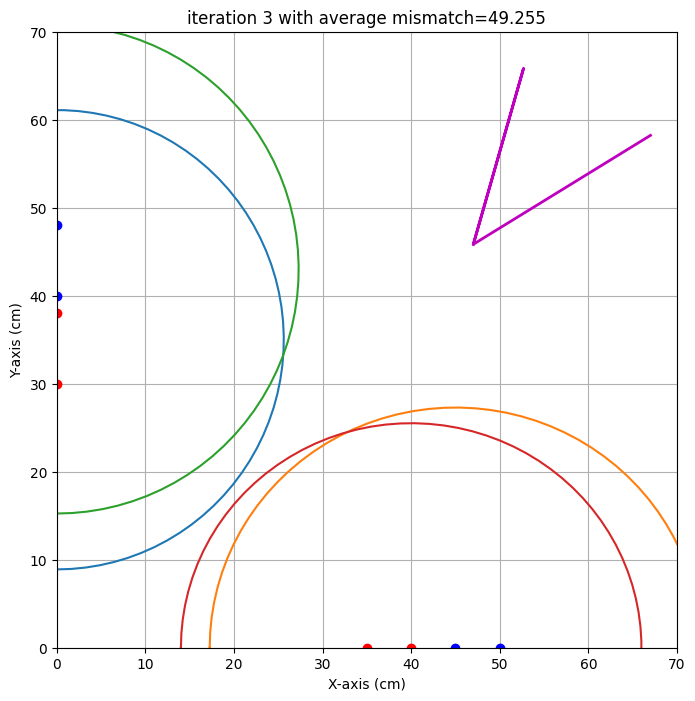

end iteration 3 with average mismatch=49.255


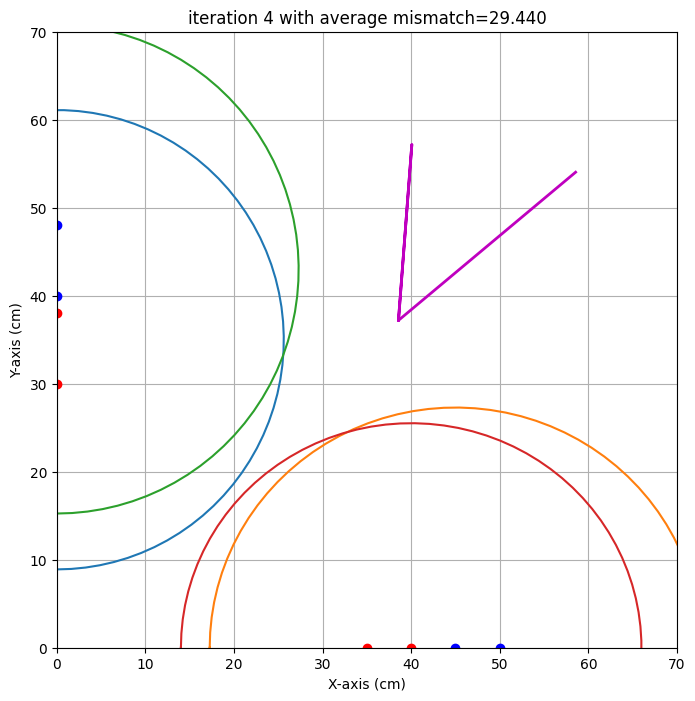

end iteration 4 with average mismatch=29.440


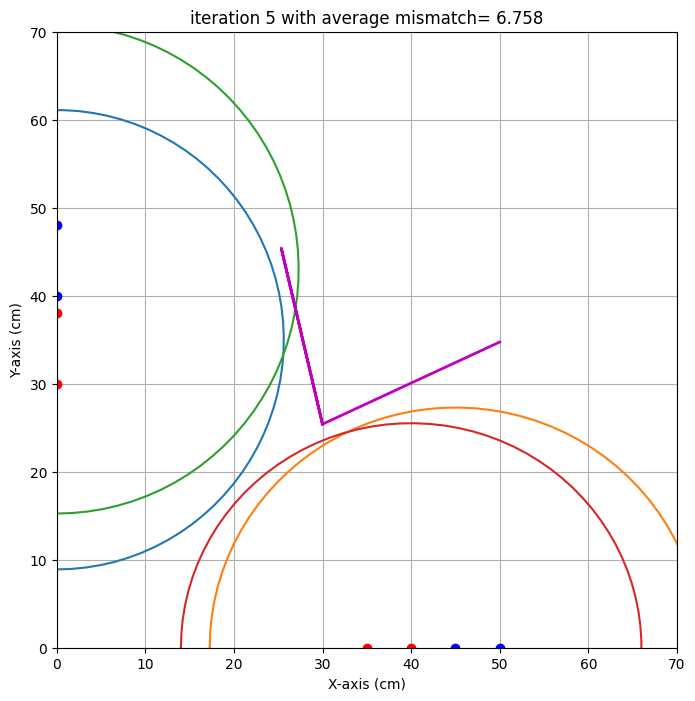

end iteration 5 with average mismatch= 6.758


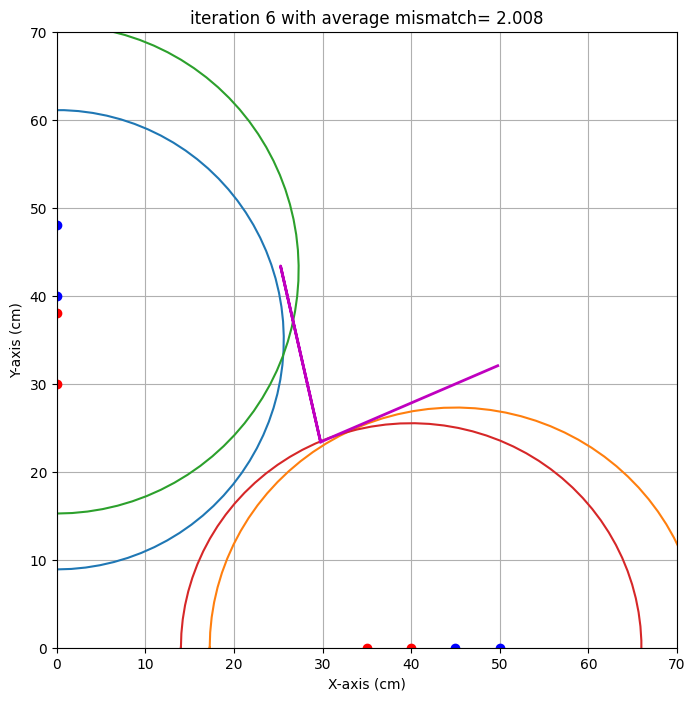

end iteration 6 with average mismatch= 2.008
end iteration 7 with average mismatch= 1.875
end iteration 8 with average mismatch= 1.765
end iteration 9 with average mismatch= 1.765
end iteration 10 with average mismatch= 1.765
end iteration 11 with average mismatch= 1.765
end iteration 12 with average mismatch= 1.765
end iteration 13 with average mismatch= 1.764
end iteration 14 with average mismatch= 1.764
end iteration 15 with average mismatch= 1.764
end iteration 16 with average mismatch= 1.764
end iteration 17 with average mismatch= 1.764
end iteration 18 with average mismatch= 1.764
end iteration 19 with average mismatch= 1.764
end iteration 20 with average mismatch= 1.678
end iteration 21 with average mismatch= 1.670
end iteration 22 with average mismatch= 1.588
end iteration 23 with average mismatch= 1.548
end iteration 24 with average mismatch= 1.546
end iteration 25 with average mismatch= 1.546
end iteration 26 with average mismatch= 1.546
end iteration 27 with average mismatch

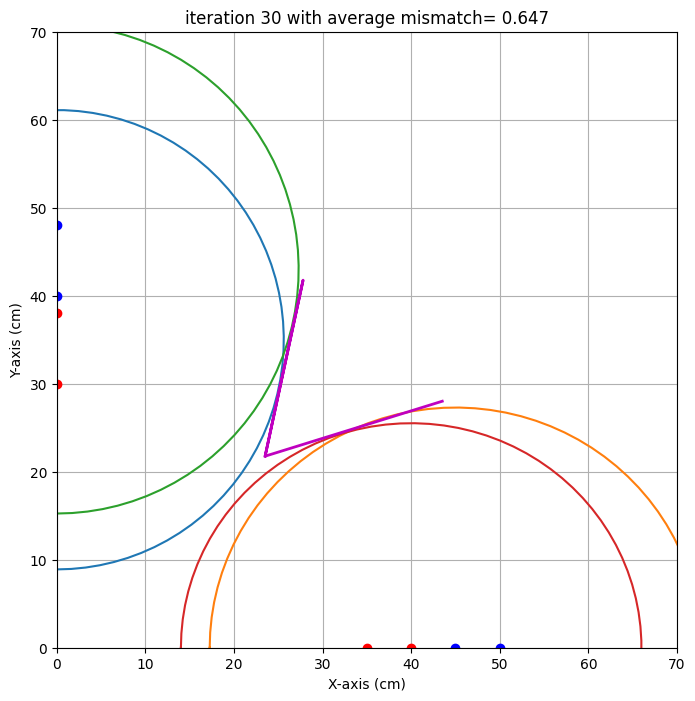

end iteration 30 with average mismatch= 0.647
###############################################################################
end of iteration  30
Best alpha=  17.34 with uncertainty=  11.14
Best beta =  12.09 with uncertainty=   8.09
Best x0   =  23.51 with uncertainty=   1.86
Best y0   =  21.77 with uncertainty=   2.33
###############################################################################


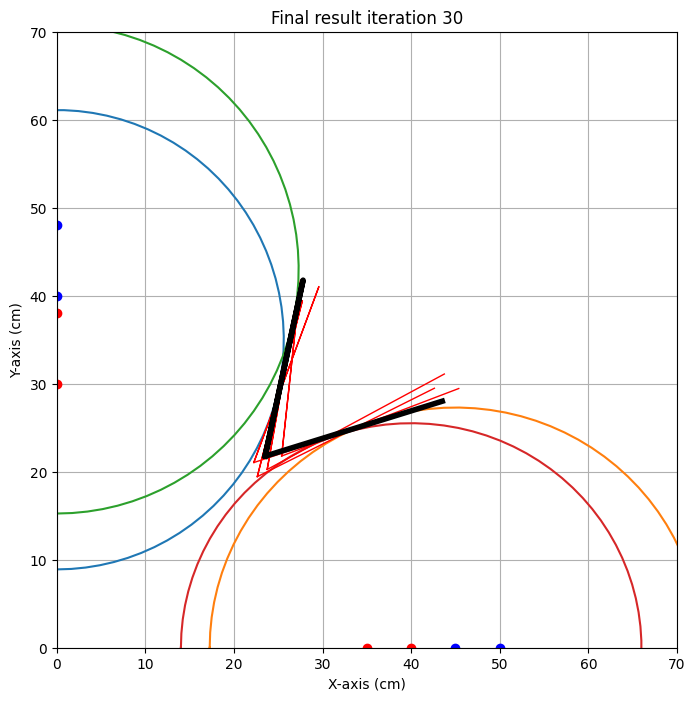

{'alpha': np.float64(17.339054750056725), 'alpha_eps': np.float64(11.139807865669148), 'beta': np.float64(12.094869899739752), 'beta_eps': np.float64(8.085502021600536), 'x0': np.float64(23.507563554119134), 'x0_eps': np.float64(1.861530422833198), 'y0': np.float64(21.767372610080212), 'y0_eps': np.float64(2.332963148146316)}
test locatie 
x0 target is : 21.0. Gevonden waarde: 23.5 cm met een standaardafwijking van 1.9 cm 
y0 target is : 18.9. Gevonden waarde: 21.8 cm met een standaardafwijking van 2.3 cm 
alpha target is : 17.0. Gevonden waarde: 17.3 graden met een standaardafwijking van 11.1 graad 
beta target is : 11.0. Gevonden waarde: 12.1 graden met een standaardafwijking van 8.1 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 21,  # zelf aanvullen,
                    'y0': 18.9, # zelf aanvullen,
                    'alpha' : 17, # zelf aanvullen,
                    'beta' : 11  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # [0, 60, 60,0, 0.36] ongeldig meting
                    # [0,55, 55, 0, 0.36] ongeldig meting
                    # [0, 50, 50, 0, 0.36] ongeldig
                    #[0, 40, 0, 50, 57.7 ],
                    [0, 30, 0, 40, 52.2],
                    #[0, 20, 0, 30, 50.0],
                    [40, 0, 50, 0, 55.5],
                    # [30, 0, 40, 0, 50.5],
                    # [20, 0, 30, 0, 0.36] ongeldig
                    #[35, 0, 45, 0, 53.5],
                    [0, 38, 0, 48, 55.5],
                    #[0, 22, 0, 32, 48.1],
                    [35, 0, 45, 0, 52.0]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
#### algoritme [Sam]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="Sam.jpeg" width="400">

## Uitleg Sam
The algorithim starts on the x-axis, the reciever is placed in the furthest point on that axis, the sensor at the origin placed at a 45 degree outward facing angle, measurements are taken every 10cm until the reciever is 10cm from the origin. the proceedure is repeated following the y-axis, until the reciever is again 10cm away from the origin along the y-axis.

#### algoritme [Cedric]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Cedric.jpeg" width="400">

## Uitleg Cedric
Door de source op de x-as te zetten en de reciever op de y-as, kan je ipv. de afstand die de geluidsgolven afleggen meten, bekijken of er tussen de source en reciever wel of niet een obstakel staat. Hierdoor kan je erg snel al de helft van het veld elimineren van gemeten worden, of heb je direct de positie van het papier, waardoor je erg gericht kan gaan meten.

#### algoritme [Eline]
Voeg een foto in van het algoritme van het derde groepslid
<img src="Eline.jpeg" width="400">

## Uitleg Eline
Je zet source en receiver op uiterste rand en het midden van de y-as en kijkt of er een redelijke meting uitkomt. Als dit zo is, zet je receiver op uiterste rand en 3/4 van de y-as. Dit itereer je zodat je steeds nauwkeuriger uitkomt op de plaats van het hoekpunt. Analoog benader je het op de x-as.

We begonnen met iteratie 1 van Cedric. Deze methode leverde echter niks op, aangezien Cedric's methode alleen toepasbaar was voor alpha=beta=0. Toen begonnen we aan iteratie 2 van Sam. Sam had een goede meetmethode maar het kostte erg veel metingen en het was dus een dure procedure. Het uitvoeren van de methode van Eline is weggelaten omdat het hoogstwaarschijnlijk boven de 15 metingen zou kosten. 

Voor iteratie 3 combineren we iteratie 1 en 2. We beginnen met de eerste stap van Cedric (het vlak opdelen in 2 driehoeken om globale locatie van object te localiseren). Daarna passen we precieze bepaling van Sam toe.

Figuur: ![Alt](Final.algoritme.schets.combination.jpeg)
iteratie 3

### Conclusie en Discussie

De reden dat onze uiteindelijke proefmeting niet een nauwkeurigheid van 1 cm in (x0,y0) heeft behaald, is te wijten aan onze kalibratie. De sensor (het zilveren 'oogje') zit niet exact in het midden van de houten houder. Als je de houder op de 10 cm lijn zet, zit de sensor zelf misschien op 10,5 cm of 9,5 cm. Omdat je in je algoritme werkt met een gemiddelde waarde per 10 cm, wordt deze constante afwijking niet gecorrigeerd. Hierdoor verschuift je hele meting systematisch, wat die afwijking van $> 1$ cm in $x_0$ verklaart.

Ons algoritme is redelijk goed gelukt. Echter, denken we wel dat we in de uiteindelijke proefmeting, sommige metingen iets te kort op elkaar hebben uitgevoerd. Zoals te zien in de data, leverden veel posities namelijk ongeldige metingen op (waarschijnlijk door een te scherpe reflectiehoek). Deze metingen, die met een erg groot gedeelte van de rand van de ellips op de rand van het object zat, zijn eruit gehaald. 

Uiteindelijk kwamen hier 4 redelijke metingen (met systematische fout) uit. Dit is een erg beperkte dataset die niet noodzakelijkerwijs de meest nauwkeurige oplossing biedt. 